In [19]:
from pathlib import Path
import shutil, requests
from PIL import Image
input_base = Path("/var/internet_imgs")
WORK_DIR = Path("/kaggle/working/Internet_masked_imgs")
IMAGE_URLS =["000000000285.jpg","000000000785.jpg"]
WORK_DIR.mkdir(parents=True, exist_ok=True)
exts = {".jpg",".jpeg",".png",".bmp",".tif",".tiff",".webp"}
uploaded = sorted([p for p in input_base.rglob("*") if p.suffix.lower() in exts]) if input_base.exists() else []

if uploaded:
    for p in uploaded:
        dest = WORK_DIR / p.name
        if dest.exists():
            base, ext = p.stem, p.suffix
            k = 1
            while (WORK_DIR / f"{base}_{k}{ext}").exists(): k += 1
            dest = WORK_DIR / f"{base}_{k}{ext}"
        shutil.copy(p, dest)
    print(f"Copied {len(uploaded)} files from {WORK_DIR}")
else:
    downloaded = 0
    for i, url in enumerate(IMAGE_URLS):
        out = WORK_DIR / f"webimg_{i:03d}.jpg"
        try:
            r = requests.get(url, stream=True, timeout=12)
            if r.status_code == 200:
                with open(out, "wb") as f:
                    for chunk in r.iter_content(8192):
                        if chunk: f.write(chunk)
                try:
                    Image.open(out).verify()
                    downloaded += 1
                except Exception:
                    out.unlink(missing_ok=True)
        except Exception:
            pass
    print(f"Downloaded {downloaded} images to {WORK_DIR}")
files = sorted([p for p in WORK_DIR.iterdir() if p.suffix.lower() in exts])
print(f"No.of images available are: {len(files)}")


Copied 8 files from /kaggle/working/Internet_masked_imgs
No.of images available are: 8


Loaded Model successfully from /kaggle/working/best_seg_model.pth
Found 8 input images in /kaggle/working/Internet_masked_imgs


Predicting: 100%|██████████| 8/8 [00:06<00:00,  1.16it/s]


Saved outputs for 8 images to /kaggle/working/pred_masks


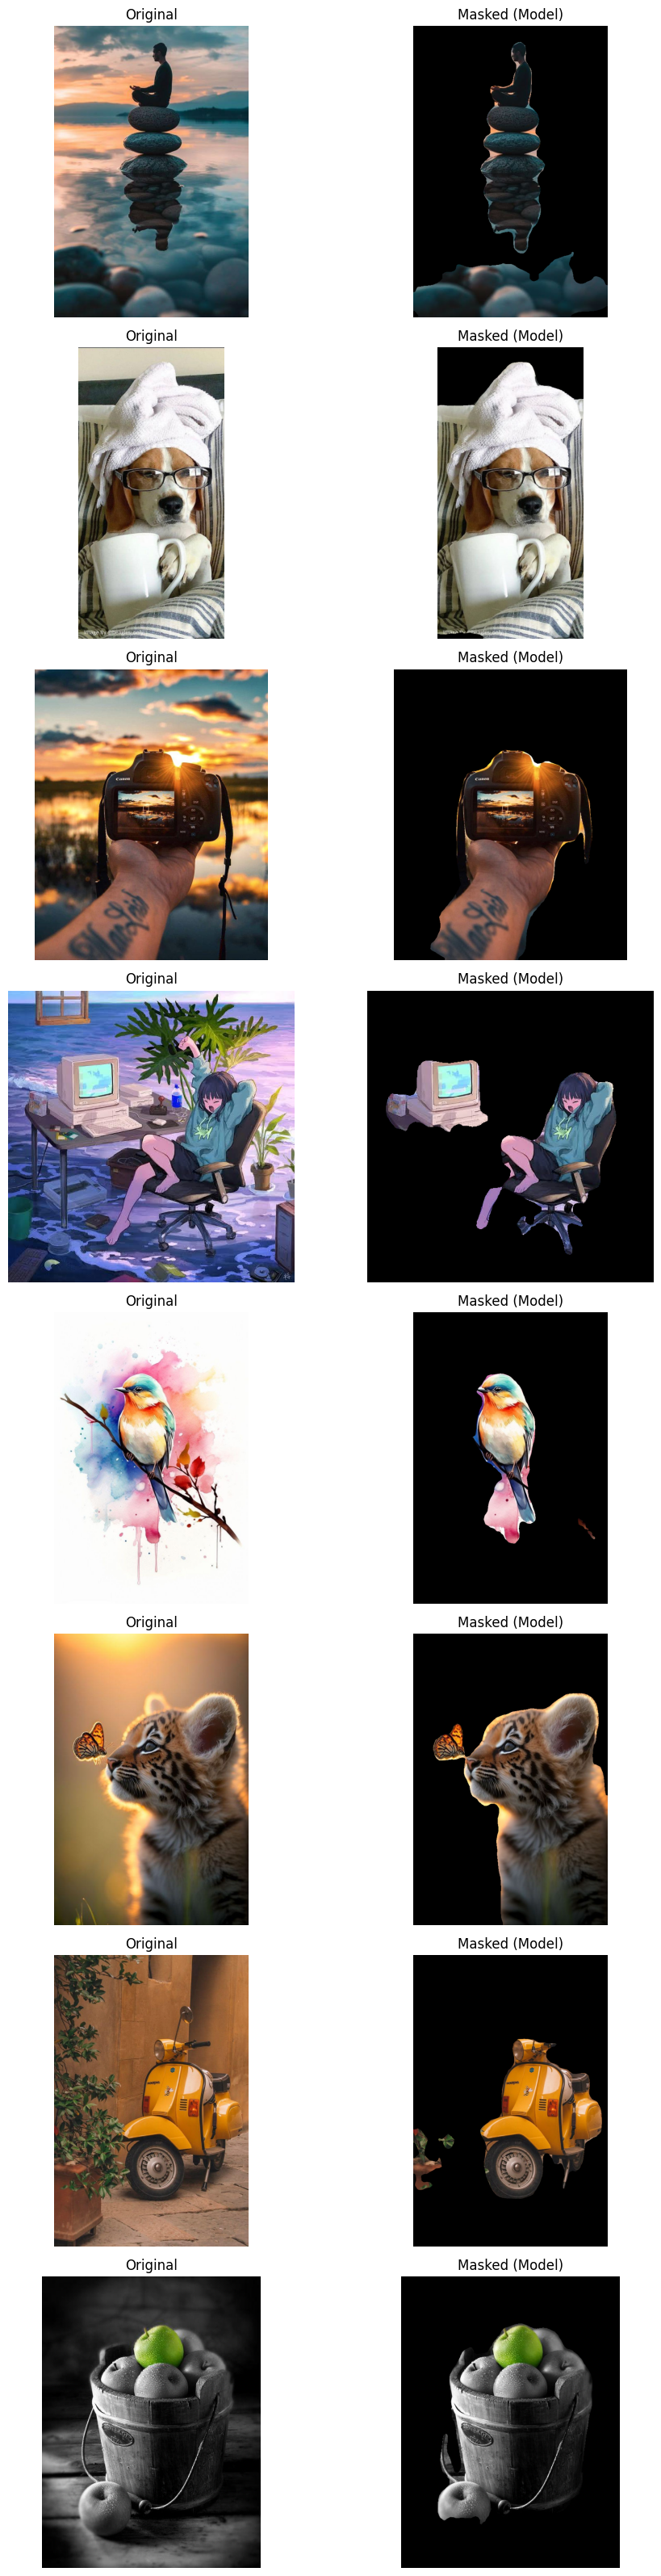

In [30]:
import os
from pathlib import Path
import random
import numpy as np
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt
import cv2
import torch
import torch.nn.functional as F
import torchvision.models.segmentation as segmentation_models
from scipy import ndimage as ndi
CONFIG = {
    "images_dir": "/kaggle/working/Internet_masked_imgs",
    "pred_masks_dir": "/kaggle/working/pred_masks",
    "state_dict_path": "/kaggle/working/best_seg_model.pth",
    "img_size": (512, 512),
    "device": "cuda" if torch.cuda.is_available() else "cpu",
    "tta_scales": [1.0, 0.75, 1.25],
    "tta_flip": True,
    "use_crf": False,
    "crf_iters": 5,
    "fg_thresh": 0.4,
    "min_area": 300,
    "keep_largest": False,
    "preview_samples": 13,
}

Path(CONFIG["pred_masks_dir"]).mkdir(parents=True, exist_ok=True)
def pil_imread_rgb(path):
    im = Image.open(path)
    try:
        ex = im._getexif()
        if ex is not None:
            from PIL import ExifTags
            for k, v in ExifTags.TAGS.items():
                if v == 'Orientation': orientation_key = k; break
            orient = ex.get(orientation_key, None)
            if orient == 3: im = im.rotate(180, expand=True)
            elif orient == 6: im = im.rotate(270, expand=True)
            elif orient == 8: im = im.rotate(90, expand=True)
    except Exception:
        pass
    im = im.convert("RGB")
    return np.array(im)

def load_model( state_path: str, device: str, num_classes: int = 2):
    dev = torch.device(device)
    model = None
    model = segmentation_models.deeplabv3_resnet50(pretrained=False, progress=True, num_classes=num_classes)
    state = Path(state_path)
    if not state.exists():
        print("Warning: state_dict not found at", state, "-> returning uninitialized model (will give garbage predictions).")
        model.to(dev).eval()
        return model
    sd = torch.load(str(state), map_location="cpu")
    if isinstance(sd, dict) and ("model_state_dict" in sd or "model_state" in sd or "state_dict" in sd):
        for k in ("model_state_dict", "model_state", "state_dict"):
            if k in sd:
                sd = sd[k]
                break
    try:
        model.load_state_dict(sd)
        print("Loaded Model successfully from", state)
    except Exception:
        sd2 = { (k.replace("module.","") if isinstance(k,str) else k): v for k,v in sd.items() }
        model.load_state_dict(sd2)
        print("Loaded state_dict after stripping 'module.' prefix.")
    model.to(dev).eval()
    return model

def preprocess_image_cv2(img_rgb, target_size):
    h, w = target_size
    img = cv2.resize(img_rgb, (w, h), interpolation=cv2.INTER_LINEAR).astype(np.float32) / 255.0
    mean = np.array([0.485,0.456,0.406], dtype=np.float32)
    std  = np.array([0.229,0.224,0.225], dtype=np.float32)
    img = (img - mean[None,None,:]) / std[None,None,:]
    img = img.transpose(2,0,1)
    return torch.from_numpy(img).unsqueeze(0).float()

def crf_refine(prob_fg, img_rgb, n_iters=5):
    return prob_fg
    h,w = prob_fg.shape
    probs = np.stack([1.0 - prob_fg, prob_fg], axis=0).astype(np.float32)
    d = dcrf.DenseCRF2D(w, h, 2)
    unary = unary_from_softmax(probs)
    d.setUnaryEnergy(unary)
    d.addPairwiseGaussian(sxy=3, compat=3)
    d.addPairwiseBilateral(sxy=60, srgb=5, rgbim=img_rgb, compat=5)
    Q = d.inference(n_iters)
    res = np.array(Q).reshape((2,h,w))[1]
    return np.clip(res, 0.0, 1.0)

def postprocess_mask(prob_map, fg_thresh=0.3, min_area=300, keep_largest=False, morph_open_k=5, morph_close_k=11):
    mask = (prob_map >= fg_thresh).astype(np.uint8)
    if morph_close_k > 0:
        kernel_close = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (morph_close_k,morph_close_k))
        mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel_close)
    if morph_open_k > 0:
        kernel_open = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (morph_open_k,morph_open_k))
        mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel_open)
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)
    out = np.zeros_like(mask)
    comps = []
    for lab in range(1, num_labels):
        area = int(stats[lab, cv2.CC_STAT_AREA])
        if area >= min_area:
            comps.append((lab, area))
            out[labels == lab] = 1
    if keep_largest and len(comps) > 0:
        comps.sort(key=lambda x: x[1], reverse=True)
        lab = comps[0][0]
        out = (labels == lab).astype(np.uint8)
    out = ndi.binary_fill_holes(out).astype(np.uint8)
    if morph_open_k > 0:
        out = cv2.morphologyEx(out.astype(np.uint8), cv2.MORPH_OPEN, kernel_open)
    return (out * 255).astype(np.uint8)

def predict_tta_multi_scale(img_rgb, model, device, model_input_size, scales=[1.0], flip=True, use_crf=False, crf_iters=5):
    H, W = img_rgb.shape[:2]
    preds = []
    for s in scales:
        new_h = max(1, int(H * s)); new_w = max(1, int(W * s))
        img_s = cv2.resize(img_rgb, (new_w, new_h), interpolation=cv2.INTER_LINEAR)
        inp = preprocess_image_cv2(img_s, model_input_size).to(device)
        with torch.no_grad():
            out = model(inp)
            logits = out['out'] if isinstance(out, dict) else out
            prob = F.softmax(logits, dim=1).cpu().numpy()[0,1,:,:]
        prob_up_scaled = cv2.resize(prob, (new_w, new_h), interpolation=cv2.INTER_LINEAR)
        prob_up_orig = cv2.resize(prob_up_scaled, (W, H), interpolation=cv2.INTER_LINEAR)
        preds.append(prob_up_orig)
        if flip:
            img_sf = img_s[:, ::-1, :].copy()
            inp_f = preprocess_image_cv2(img_sf, model_input_size).to(device)
            with torch.no_grad():
                out_f = model(inp_f)
                logits_f = out_f['out'] if isinstance(out_f, dict) else out_f
                prob_f = F.softmax(logits_f, dim=1).cpu().numpy()[0,1,:,:]
            prob_f_scaled = prob_f[:, ::-1]
            prob_f_up = cv2.resize(prob_f_scaled, (W, H), interpolation=cv2.INTER_LINEAR)
            preds.append(prob_f_up)
    avg = np.mean(np.stack(preds, axis=0), axis=0)
    if use_crf:
        avg = crf_refine(avg.astype(np.float32), img_rgb, n_iters=crf_iters)
    return np.clip(avg, 0.0, 1.0)
device = CONFIG["device"]
model = load_model(CONFIG["state_dict_path"], device=device, num_classes=2)

img_dir = Path(CONFIG["images_dir"])
pred_dir = Path(CONFIG["pred_masks_dir"])
img_files = sorted([p for p in img_dir.iterdir() if p.suffix.lower() in (".jpg",".jpeg",".png",".bmp",".tif",".tiff",".webp")])
print("Found", len(img_files), "input images in", img_dir)

saved_stems = []
for p in tqdm(img_files, desc="Predicting"):
    try:
        img = pil_imread_rgb(p)
    except Exception as e:
        print("Skipping", p, "read error:", e); continue

    prob_map = predict_tta_multi_scale(img, model, device, CONFIG["img_size"],
                                       scales=CONFIG["tta_scales"], flip=CONFIG["tta_flip"],
                                       use_crf=(CONFIG["use_crf"]), crf_iters=CONFIG["crf_iters"])

    pred_mask = postprocess_mask(prob_map, fg_thresh=CONFIG["fg_thresh"],
                                 min_area=CONFIG["min_area"], keep_largest=CONFIG["keep_largest"])
    pred_mask_orig = pred_mask
    pred_bin = (pred_mask_orig > 127).astype(np.uint8)
    masked_model = img.copy()
    masked_model[pred_bin==0] = 0
    stem = p.stem
    Image.fromarray(img).save(pred_dir / (stem + "_orig.jpg"))
    Image.fromarray(masked_model).save(pred_dir / (stem + "_model_masked.png"))
    Image.fromarray(pred_mask_orig).save(pred_dir / (stem + "_pred_mask.png"))
    saved_stems.append(stem)

print("Saved outputs for", len(saved_stems), "images to", pred_dir)
n_show = min(CONFIG["preview_samples"], len(saved_stems))
if n_show == 0:
    print("No saved images to preview.")
else:
    random.seed(123)
    picks = random.sample(saved_stems, n_show) if len(saved_stems) > n_show else saved_stems
    fig, axes = plt.subplots(n_show, 2, figsize=(10, 4 * n_show))
    if n_show == 1:
        axes = np.expand_dims(axes, 0)
    for i, stem in enumerate(picks):
        orig = np.array(Image.open(pred_dir / (stem + "_orig.jpg")).convert("RGB"))
        model_masked = np.array(Image.open(pred_dir / (stem + "_model_masked.png")).convert("RGB"))
        axes[i,0].imshow(orig); axes[i,0].axis("off"); axes[i,0].set_title("Original")
        axes[i,1].imshow(model_masked); axes[i,1].axis("off"); axes[i,1].set_title("Masked (Model)")
    plt.tight_layout(); plt.show()
